In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import norm
import matplotlib

import jax.numpy as jnp
from jax import config, random
import numpyro, jax
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
config.update('jax_enable_x64', True)
numpyro.set_platform('cpu') 
num_chains = 4
numpyro.set_host_device_count(num_chains)
print ('# jax device count:', jax.local_device_count())

from jnkepler.jaxttv import JaxTTV
from jnkepler.jaxttv import ttv_default_parameter_bounds, ttv_optim_curve_fit, scale_pdic
import corner

# jax device count: 4


In [2]:
TESS_offset = 2457000

In [3]:
d = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_73209/3592144059.py:1: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


In [4]:
### get times, errs from the data
list_of_obs_transit_times = []
list_of_transit_time_errs = []

period_guess = [28.579657965796578, 38.35013501350135]
# period_guess = [8.88, 28.579657965796578, 38.35013501350135]
for j in range(2):
    list_of_obs_transit_times.append(np.array(d.Tc[d.Planet_num==j+2]))
    list_of_transit_time_errs.append(np.array(d.Tc_err[d.Planet_num==j+2]))
# for j in range(3):
#     list_of_obs_transit_times.append(np.array(d.Tc[d.Planet_num==j+1]))
#     list_of_transit_time_errs.append(np.array(d.Tc_err[d.Planet_num==j+1]))
# index_obs_1 = np.array(d.Index[d.Planet_num==1])
index_obs_2 = np.array(d.Index[d.Planet_num==2])
index_obs_3 = np.array(d.Index[d.Planet_num==3])

tcobs = []
errorobs = []
for j in range(2):
    tcobs.append(np.array(d.Tc[d.Planet_num == j + 2]))
    errorobs.append(np.array(d.Tc_err[d.Planet_num == j + 2]))
# for j in range(3):
#     tcobs.append(np.array(d.Tc[d.Planet_num == j + 1]))
#     errorobs.append(np.array(d.Tc_err[d.Planet_num == j + 1]))


# Inflate errors by factor of 3
inflation_factor = 6
inflated_errorobs = [errs * inflation_factor for errs in errorobs]
inflated_list_of_transit_time_errs = [errs * inflation_factor for errs in list_of_transit_time_errs]

# Optional: print to check
print("Original errors:", errorobs[1])
print("Inflated errors:", inflated_errorobs[1])

print(tcobs)


Original errors: [0.00223831 0.001001   0.00223831 0.00500501 0.00141563 0.01205365
 0.00141563 0.00153307 0.00447661 0.00223831 0.00141563 0.00141563
 0.00231437 0.00141563 0.00141563 0.00223831 0.00141563]
Inflated errors: [0.01342986 0.006006   0.01342986 0.03003006 0.00849378 0.0723219
 0.00849378 0.00919842 0.02685966 0.01342986 0.00849378 0.00849378
 0.01388622 0.00849378 0.00849378 0.01342986 0.00849378]
[array([1726.0548675 , 1754.6333655 , 1783.2118635 , 1811.7993705 ,
       1840.3748655 , 1897.5358655 , 1926.1163655 , 2440.54534548,
       2640.60684348, 2697.77184748, 2726.35334848, 2812.09685048,
       2840.67334648, 2926.41985149, 3297.97035549, 3355.12935349,
       3383.71185549, 3440.87685949, 3555.19485549, 3583.77235249,
       3612.34984948, 3640.93034948]), array([1743.5532885 , 1781.9036865 , 1820.26509551, 1896.9618875 ,
       1973.6636845 , 2433.91650852, 2625.67250252, 2664.02490252,
       2702.35327849, 2740.7176905 , 2817.41147949, 2932.46267349,
       33

In [5]:
### run JaxTTV sim
t_start = 1723.  # start of integration
# t_end = 5500. # end of integration
t_end = 3670.
dt = 0.1 # integration timestep

jttv = JaxTTV(t_start, t_end, dt, tcobs, period_guess, errorobs=errorobs, print_info=True)


# number of transiting planets:    2
# integration starts at:           1723.00
# first transit time in data:      1726.05
# last transit time in data:       3661.13
# integration ends at:             3670.00
# integration time step:           0.1000 (1/285 of innermost period)



In [6]:
### set bounds for fit
param_bounds = ttv_default_parameter_bounds(jttv, emax=0.5)
# Add bounds for cosi and lnode
npl = jttv.nplanet
# param_bounds["cosi"] = [0.0*np.ones(npl), 0.1*np.ones(npl)]   # 
# param_bounds["lnode"] = [0.0*np.ones(npl), 2*np.pi*np.ones(npl)]  # full circle
print(param_bounds)


### initialize p_init: p1,p2,ecosw1,ecosw2,esinw1,esinw2,tic1,tic2,lnpmass1,lnpmass2
### using best fit for run with all points
p_init = np.array([28.579657965796578, 38.35013501350135, # P
                   -0.0021369753, -0.0018361236,  # ecosw
                   -0.0023016884, -0.0019734158,  # esinw
                   # 0.0, 0.0,  # cosi
                   # 0.0, 0.0, # Omega
                   1726.05430737, 1743.55228223, # tic
                   -10.97106092, -11.30491702]) # lnpmass


{'tic': [array([1726.0048675, 1743.5032885]), array([1726.1048675, 1743.6032885])], 'period': [array([28.29386139, 37.96663366]), array([28.86545455, 38.73363636])], 'ecosw': [array([-0.5, -0.5]), array([0.49, 0.49])], 'esinw': [array([-0.5, -0.5]), array([0.49, 0.49])], 'lnpmass': [array([-16.11809565, -16.11809565]), array([-6.90775528, -6.90775528])], 'pmass': [array([1.e-07, 1.e-07]), array([0.001, 0.001])]}


In [7]:
# keys = ['period', 'ecosw', 'esinw', 'cosi', 'lnode', 'tic', 'lnpmass']
keys = ['period', 'ecosw', 'esinw', 'tic', 'lnpmass']

lb = np.hstack([param_bounds[k][0] for k in keys])
ub = np.hstack([param_bounds[k][1] for k in keys])

print("All inside bounds?", np.all(p_init >= lb) and np.all(p_init <= ub))

All inside bounds? True


In [8]:
from jnkepler.jaxttv.infer import params_to_dict

pdic_init = params_to_dict(p_init, npl, keys)
ttimes, _ = jttv.get_transit_times_obs(pdic_init)
print(pdic_init)
print("Finite?", np.isfinite(ttimes).all())
for i in range(npl):
    planet_params = {k: pdic_init[k][i] for k in keys}
    try:
        t, _ = jttv.get_transit_times_obs({k: np.array([v]) for k, v in planet_params.items()})
        print(f"Planet {i+1} OK: Transit times finite? {np.isfinite(t).all()}")
    except Exception as e:
        print(f"Planet {i+1} FAILED:", e)


{'period': array([28.57965797, 38.35013501]), 'ecosw': array([-0.00213698, -0.00183612]), 'esinw': array([-0.00230169, -0.00197342]), 'tic': array([1726.05430737, 1743.55228223]), 'lnpmass': array([-10.97106092, -11.30491702])}
Finite? True
Planet 1 OK: Transit times finite? True
Planet 2 OK: Transit times finite? True


In [9]:
import numpy as np
from copy import deepcopy
from scipy.optimize import least_squares
from jnkepler.jaxttv.infer import params_to_dict

def ttv_optim_curve_fit_safe(jttv, param_bounds_, p_init=None, max_nfev=2000):
    """
    Robust replacement for ttv_optim_curve_fit that avoids NaNs/Infs.
    Works without modifying jnkepler source code.
    """
    npl = jttv.nplanet
    param_bounds = deepcopy(param_bounds_)

    if "cosi" not in param_bounds or "lnode" not in param_bounds:
        keys = ['period', 'ecosw', 'esinw', 'tic', 'lnpmass']
    else:
        keys = ['period', 'ecosw', 'esinw', 'cosi', 'lnode', 'tic', 'lnpmass']

    lb = np.hstack([param_bounds[k][0] for k in keys])
    ub = np.hstack([param_bounds[k][1] for k in keys])

    if p_init is None:
        p_init = 0.5 * (lb + ub)

    # --- safety tweak: don't start exactly on cosi=0 or at bound ---
    cosi_idx = keys.index("cosi") * npl if "cosi" in keys else None
    if cosi_idx is not None:
        for i in range(npl):
            idx = cosi_idx + i
            if p_init[idx] <= lb[idx]:
                p_init[idx] = lb[idx] + 0.01*(ub[idx]-lb[idx])

    tc_obs = jttv.tcobs_flatten
    tc_err = jttv.errorobs_flatten

    def safe_model(params_flat):
        try:
            pdic = params_to_dict(params_flat, npl, keys)
            y, _ = jttv.get_transit_times_obs(pdic)
            if not np.isfinite(y).all():
                return None
            return np.array(y)
        except Exception:
            return None

    def residuals(params_flat):
        y = safe_model(params_flat)
        if y is None:
            return np.ones_like(tc_obs) * 1e6
        return (y - tc_obs) / tc_err

    # --- optimization ---
    res = least_squares(
        residuals,
        p_init,
        bounds=(lb, ub),
        method="trf",
        max_nfev=max_nfev,
        xtol=1e-8,
        ftol=1e-8,
    )

    popt_flat = res.x
    pdic_opt = params_to_dict(popt_flat, npl, keys)
    pdic_opt['pmass'] = np.exp(pdic_opt['lnpmass'])

    return pdic_opt


In [10]:
### fit
popt = ttv_optim_curve_fit(jttv,param_bounds,p_init=p_init, plot=False)
# popt = ttv_optim_curve_fit_safe(jttv, param_bounds, p_init=p_init)
# plt.show()
print(popt)

/opt/homebrew/anaconda3/lib/python3.12/site-packages/jnkepler/jaxttv/infer.py:97: UserWarning: Bounds for cosi/lnode not provided: assuming coplanar orbits.
  warnings.warn(


# running least squares optimization...
# objective function: 35934.58 --> 101.05 (39 data)
# elapsed time: 22.2 sec
{'period': array([28.58087828, 38.34965953]), 'ecosw': array([-0.20135602, -0.17522694]), 'esinw': array([-0.02116081, -0.01818554]), 'tic': array([1726.05286978, 1743.55345984]), 'lnpmass': array([-11.34039257, -11.85800448]), 'pmass': Array([1.18831091e-05, 7.08164395e-06], dtype=float64)}


/opt/homebrew/anaconda3/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:523: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(


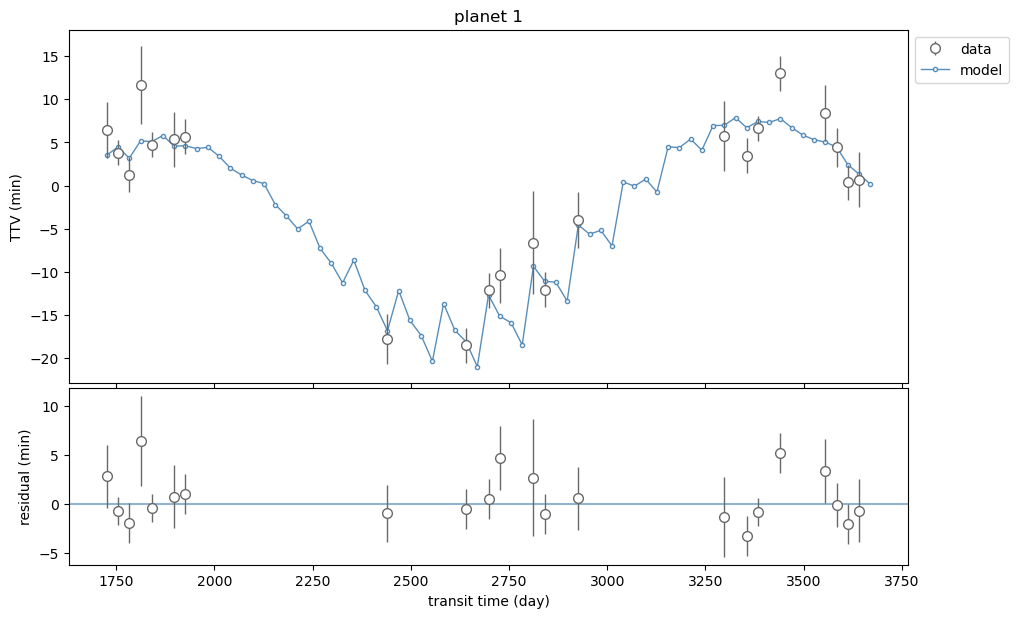

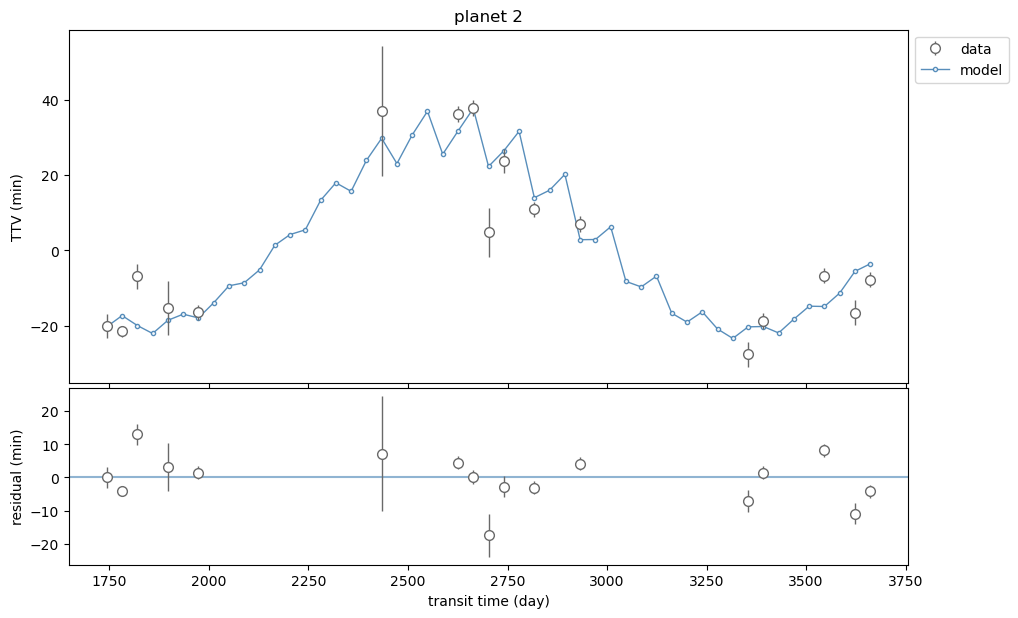

In [11]:
### plot fit
tcall = jttv.get_transit_times_all_list(popt,truncate=False)
jttv.plot_model(tcall, marker='.')
plt.show()

# fractional energy error (symplectic, dt=1.00e-01): -1.26e-10
# fractional energy error (symplectic, dt=2.86e-02): -1.04e-11
# max difference in tc: 2.36e-07 days (0.02 sec)


sample: 100%|█| 1000/1000 [00:00<00:00, 1646.73it/s, 7 steps of size 3.91e-01. a



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      lndf      2.39      1.24      2.30      0.58      4.27    110.87      1.00
     lnvar      0.62      0.38      0.65      0.05      1.21    129.67      1.00

Number of divergences: 0


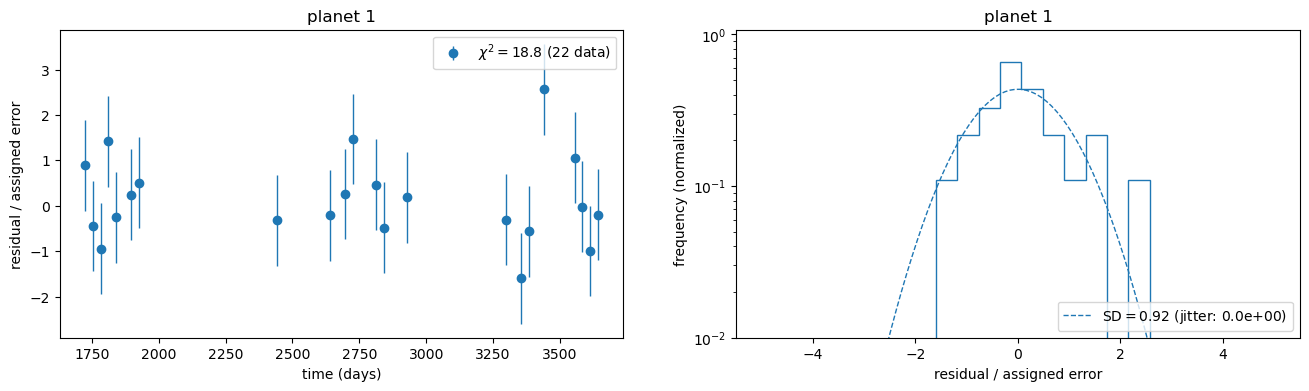

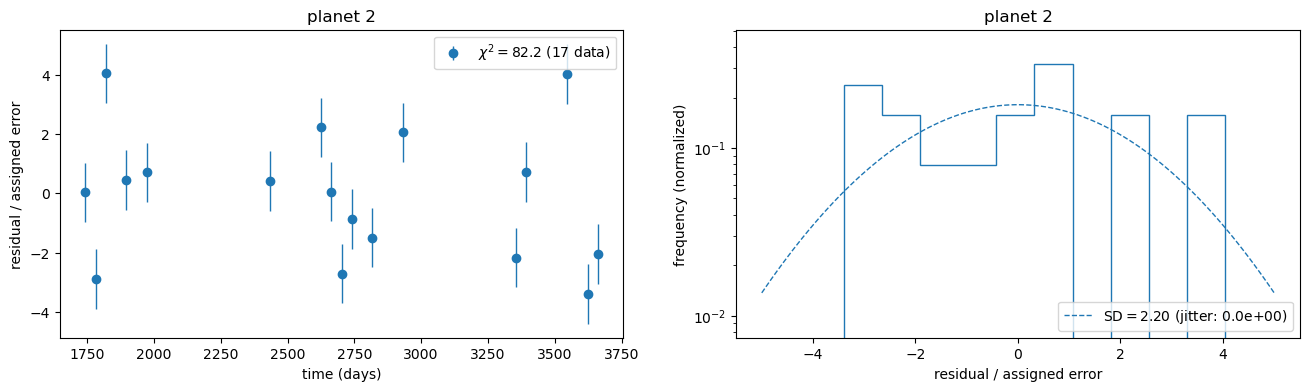

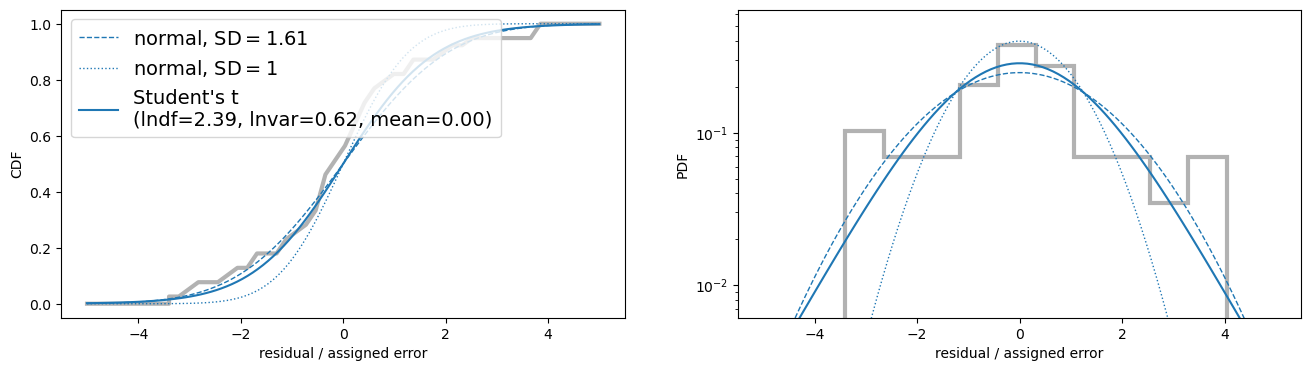

In [12]:
### check precision and residuals 
tc, _ = jttv.check_timing_precision(popt)
jitter = 5 / (24*60)
jitters = [jitter, jitter]
pdic_normal, pdic_student = jttv.check_residuals(popt)#, jitters=jitters)
plt.show()

# Load RV data fron Lubin et al 2024

In [79]:
rv_data_file = "ajad79edt3_mrt.txt"

colnames = ["BJD", "RVel", "e_RVel", "Inst", "Source", "Source_extra"]

df_rv = pd.read_csv(
    rv_data_file,
    sep=r"\s+",              # regex: split on 1+ whitespace
    comment="#",
    names=colnames,
    skiprows=31,
    engine="python",         # more flexible parser
)

# Merge Source + Source_extra
df_rv["Source"] = df_rv["Source"].fillna("") + " " + df_rv["Source_extra"].fillna("")
df_rv["Source"] = df_rv["Source"].str.strip()

# Drop the helper column
df_rv = df_rv.drop(columns=["Source_extra"])

print(df_rv.head())
print(df_rv)

            BJD   RVel  e_RVel      Inst Source
0  2.458801e+06  -8.18    3.31  CARMENES      A
1  2.458803e+06 -21.22    1.22     HIRES      B
2  2.458804e+06 -10.72    4.05  CARMENES      A
3  2.458815e+06 -11.45    2.52  CARMENES      A
4  2.458816e+06 -26.36    1.19     HIRES      B
              BJD   RVel  e_RVel      Inst     Source
0    2.458801e+06  -8.18    3.31  CARMENES          A
1    2.458803e+06 -21.22    1.22     HIRES          B
2    2.458804e+06 -10.72    4.05  CARMENES          A
3    2.458815e+06 -11.45    2.52  CARMENES          A
4    2.458816e+06 -26.36    1.19     HIRES          B
..            ...    ...     ...       ...        ...
535  2.459869e+06  10.37    2.99       APF          C
536  2.459906e+06  14.99    2.99       APF          C
537  2.460068e+06   4.15    1.89     HIRES  This work
538  2.460095e+06  -9.90    2.27     HIRES  This work
539  2.460488e+06 -31.43    0.99     HIRES  This work

[540 rows x 5 columns]


In [80]:
### convert to TESS time offset 
tess_offset_times = df_rv['BJD'] - TESS_offset
df_rv['BJD'] = tess_offset_times
print(df_rv)

            BJD   RVel  e_RVel      Inst     Source
0    1801.32215  -8.18    3.31  CARMENES          A
1    1802.79992 -21.22    1.22     HIRES          B
2    1804.37441 -10.72    4.05  CARMENES          A
3    1815.30234 -11.45    2.52  CARMENES          A
4    1815.77873 -26.36    1.19     HIRES          B
..          ...    ...     ...       ...        ...
535  2868.96530  10.37    2.99       APF          C
536  2905.85163  14.99    2.99       APF          C
537  3068.11741   4.15    1.89     HIRES  This work
538  3095.04327  -9.90    2.27     HIRES  This work
539  3487.88545 -31.43    0.99     HIRES  This work

[540 rows x 5 columns]


# Set up and run HMC

In [81]:
# def model_scaled(sample_keys, param_bounds):
#     """numpyro model for scaled parameters"""
#     par = {}

#     # sample parameters from priors
#     for key in sample_keys:
#         par[key+"_scaled"] = numpyro.sample(key+"_scaled", dist.Uniform(param_bounds[key][0]*0, param_bounds[key][0]*0+1.))
#         par[key] = numpyro.deterministic(key, par[key+"_scaled"] * (param_bounds[key][1] - param_bounds[key][0]) + param_bounds[key][0])
#     if "pmass" not in sample_keys:
#         par["pmass"] = numpyro.deterministic("pmass", jnp.exp(par["lnpmass"]))
    
#     # Jacobian for uniform ecc prior
#     ecc = numpyro.deterministic("ecc", jnp.sqrt(par['ecosw']**2+par['esinw']**2))
#     numpyro.factor("eprior", -jnp.log(ecc))

#     # compute transit times
#     # tcmodel, ediff = jttv.get_transit_times_obs(par)
#     # numpyro.deterministic("ediff", ediff)
#     # numpyro.deterministic("tcmodel", tcmodel)

#     # compute transit times + RVs
#     times_rv = jnp.array(df_rv["BJD"].values)  # times in TESS offset days
#     tcmodel, rvmodel, ediff = jttv.get_transit_times_and_rvs_obs(par, times_rv, transit_orbit_idx=np.array([0,1,2]))
#     numpyro.deterministic("ediff", ediff)
#     numpyro.deterministic("tcmodel", tcmodel)
#     numpyro.deterministic("rvmodel", rvmodel)

    
#     # TTV likelihood
#     tcerrmodel = jttv.errorobs_flatten     
#     numpyro.sample("obs", dist.Normal(loc=tcmodel, scale=tcerrmodel), obs=jttv.tcobs_flatten)

#     # RV likelihood
#     rv_obs = jnp.array(df_rv["RVel"].values)
#     rv_err = jnp.array(df_rv["e_RVel"].values)
#     numpyro.sample("obs_rv",
#                    dist.Normal(loc=rvmodel, scale=rv_err),
#                    obs=rv_obs)

In [82]:
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from jax import lax


def rho_transit_jax(P, rp, b, T14, e, omega, G_const, eps=1e-12):
    """
    JAX reimplementation of your rho_sample function.
    All inputs are arrays (shape (npl,) or broadcastable).
    Units must match your offline code: P in days, T14 in days, rho in g/cm^3, G_const in cm^3/(g*day^2).
    """
    # safe clipping & tiny epsilons to avoid division by zero
    P = jnp.asarray(P)
    rp = jnp.asarray(rp)
    b = jnp.asarray(b)
    T14 = jnp.asarray(T14)
    e = jnp.asarray(e)
    omega = jnp.asarray(omega)

    term1 = (3.0 * jnp.pi) / (G_const * (P**2) + eps)

    sine_num = T14 * jnp.pi * (1.0 + e * jnp.sin(omega))
    sine_den = P * jnp.sqrt(jnp.clip(1.0 - e**2, 0.0, 1.0) + eps) + eps
    sine_term = sine_num / sine_den
    # arcsin domain safety
    sine_term = jnp.clip(sine_term, -0.999999, 0.999999)
    sin_sq = (jnp.sin(sine_term))**2 + eps

    term2_num = (1.0 + rp)**2 - b**2
    # forbid negative due to floating roundoff
    term2_num = jnp.maximum(term2_num, eps)

    term2_frac = term2_num / sin_sq
    term2 = (term2_frac + b**2)**(3.0/2.0)

    rho = term1 * term2
    return rho

In [13]:
def model_scaled_with_literature(sample_keys, param_bounds,
                                 # literature constraints for planets: arrays length npl
                                 # P_lit=None, P_err=None,
                                 # rp_rs_lit=None, rp_rs_err=None,
                                 # b_lit=None, b_err=None,
                                 # T14_lit=None, T14_err=None,
                                 # rho_star_lit=None, rho_star_err=None,
                                 # # physical constants
                                 # G_const=None
                                ):
    """
    NumPyro model that combines TTV likelihood (tcobs) with the literature-importance-sampling
    style constraints you used offline (rp/rstar, b, T14, and the rho_star likelihood computed from them).
    - sample_keys: list of parameter keys e.g. ["ecosw","esinw","pmass","period","tic"] (same as before)
    - param_bounds: dict with bounds per key (same format you already use)
    - P_lit, rp_rs_lit, b_lit, T14_lit must be arrays of length npl; same for *_err
    - rho_star_lit and rho_star_err are scalars (Gaia/literature for host star).
    - G_const: gravitational constant in units cm^3/(g*day^2) — must be provided.
    """

    npl = jttv.nplanet
    if G_const is None:
        raise ValueError("Provide G_const (in cm^3/(g*day^2)) to keep units consistent with offline code.")

    # --- sample parameters from their scaled priors (as you did) ---
    par = {}
    for key in sample_keys:
        # scaled uniform [0,1] per planet
        par[key + "_scaled"] = numpyro.sample(key + "_scaled", dist.Uniform(jnp.zeros(npl), jnp.ones(npl)))
        lo = jnp.array(param_bounds[key][0])
        hi = jnp.array(param_bounds[key][1])
        par[key] = numpyro.deterministic(key, par[key + "_scaled"] * (hi - lo) + lo)

    # handle mass conversion if only lnpmass is present
    if "lnpmass" in par and "pmass" not in par:
        par["pmass"] = numpyro.deterministic("pmass", jnp.exp(par["lnpmass"]))

    # eccentricity, omega
    # ecc = jnp.sqrt(par['ecosw']**2 + par['esinw']**2)
    # omega = jnp.arctan2(par['esinw'], par['ecosw'])
    # numpyro.deterministic("ecc", ecc)
    # numpyro.deterministic("omega", omega)
    # Jacobian for uniform ecc prior
    ecc = numpyro.deterministic("ecc", jnp.sqrt(par['ecosw']**2+par['esinw']**2))
    numpyro.factor("eprior", -jnp.log(ecc))

    # --- TTV model for transit times (same as before) ---
    tcmodel, ediff = jttv.get_transit_times_obs(par)
    numpyro.deterministic("tcmodel", tcmodel)
    numpyro.deterministic("ediff", ediff)

    # observational TTV likelihood (unchanged)
    lntcjitter = numpyro.sample("lntcjitter", dist.Uniform(low=jnp.log(0.3/1440.), high=jnp.log(15./1440.)))
    tcjitter = numpyro.deterministic("tcjitter", jnp.exp(lntcjitter))
    tcerrmodel = jnp.sqrt(jttv.errorobs_flatten**2 + tcjitter**2)
    numpyro.sample("obs_tc", dist.Normal(loc=tcmodel, scale=tcerrmodel), obs=jttv.tcobs_flatten)

    # ------------------------------------------------------------------
    # Now: implement the "importance sampling" constraints from literature
    # For each planet we create latent variables drawn from the literature posteriors:
    # rp_rs_latent ~ Normal(rp_rs_lit, rp_rs_err)
    # b_latent    ~ Normal(b_lit, b_err)
    # T14_latent  ~ Normal(T14_lit, T14_err)
    # Then compute rho_transit from these latents and par['period'], ecc, omega using rho_transit_jax
    # and compare rho_transit to rho_star_lit with a Normal likelihood.
    # ------------------------------------------------------------------

    # # ensure the literature inputs are arrays/jnp arrays
    # if rp_rs_lit is None or b_lit is None or T14_lit is None:
    #     raise ValueError("You must pass P_lit, rp_rs_lit, b_lit, T14_lit arrays (one per planet).")

    # # P_lit_j = jnp.array(P_lit)
    # # P_err_j = jnp.array(P_err)
    # rp_rs_lit_j = jnp.array(rp_rs_lit)
    # rp_rs_err_j = jnp.array(rp_rs_err)
    # b_lit_j = jnp.array(b_lit)
    # b_err_j = jnp.array(b_err)
    # T14_lit_j = jnp.array(T14_lit)
    # T14_err_j = jnp.array(T14_err)

    # # --- sample latent parameters from literature posteriors (these act like the draws you made offline) ---
    # # We sample them with Normal priors centered on literature values (this is equivalent to drawing and resampling)
    # rp_rs_latent = numpyro.sample("rp_rs_latent", dist.Normal(rp_rs_lit_j, rp_rs_err_j))
    # b_latent = numpyro.sample("b_latent", dist.Normal(b_lit_j, b_err_j))
    # T14_latent = numpyro.sample("T14_latent", dist.Normal(T14_lit_j, T14_err_j))

    # # Expose latents (so they appear in samples)
    # # numpyro.deterministic("rp_rs_latent", rp_rs_latent)
    # # numpyro.deterministic("b_latent", b_latent)
    # # numpyro.deterministic("T14_latent", T14_latent)

   

    
    # # Compute rho_transit for each planet from sampled latents + modeled e, omega, P
    # rho_transit = rho_transit_jax(par['period'], rp_rs_latent, b_latent, T14_latent, ecc, omega, G_const)
    # numpyro.deterministic("rho_transit", rho_transit)

    # # Compare each rho_transit to the literature/Gaia rho_star (same star). If rho_star_lit is scalar,
    # # we observe the same scalar from each planet's rho_transit (so the likelihood multiplies).
    # # if rho_star_lit is not None and rho_star_err is not None:
    # #     # Broadcast rho_star_lit and err if needed
    # #     rho_obs = jnp.array(rho_star_lit)
    # #     rho_err = jnp.array(rho_star_err)
    # #     # Create likelihood terms: each planet contributes
    # #     for i in range(npl):
    # #         numpyro.sample(f"rho_like_planet{i+1}",
    # #                        dist.Normal(rho_transit[i], rho_err),
    # #                        obs=rho_obs)

    # # compare rho_transit to observed stellar density
    # numpyro.sample("rho_like", dist.Normal(rho_transit, rho_star_err), obs=jnp.full(npl, rho_star_lit))


In [14]:
# physical parameters to sample from
# sample_keys = ['period', 'ecosw', 'esinw', 'cosi', 'lnode', 'tic', 'lnpmass'] # uniform mass prior
sample_keys = ['period', 'ecosw', 'esinw', 'tic', 'lnpmass']

In [15]:
# scaled parameters
pdic_scaled = scale_pdic(popt, param_bounds)

In [94]:
###  values from lubin 2022
rho_star = 1.37 #[g/cm^3] 
rho_star_err = 0.11 #/10

T14_2 = 4.5 * 0.0416667
T14_2_err = (0.2 * 0.0416667) #/ 10
b_2 = 0.63
b_2_err = 0.02 #/10
rp_2 = 0.0306
rp_2_err = 0.0007 #/ 10

T14_3 = 5.5 * 0.0416667
T14_3_err =(0.30 * 0.0416667) #/ 10
b_3 = 0.48
b_3_err = 0.04 #/ 10
rp_3 = 0.0302
rp_3_err = 0.0007 #/ 10

In [95]:
rp_rs_lit = [rp_2, rp_3]
rp_rs_err = [rp_2_err, rp_3_err]
b_lit = [b_2, b_3]
b_err = [b_2_err, b_3_err]
T14_lit = [T14_2, T14_3]         # in days
T14_err = [T14_2_err, T14_3_err]
rho_star_lit = rho_star
rho_star_err = rho_star_err

from astropy.constants import G
from astropy import units as u
G_new_units = G.to(u.cm**3 / (u.g * u.day**2))
G_const = G_new_units.value

In [16]:
### initializing mass matrix
# information matrix and parameter covariance
from jnkepler.jaxttv.information import information
fisher_information = information(jttv, popt, sample_keys)
parameter_cov = jnp.linalg.inv(fisher_information)

for i,key in enumerate(sample_keys):
    print(key, np.diag(jnp.sqrt(parameter_cov))[3*i:3*i+3])

# Fisher information and parameter covariance matrix for scaled parameters
fisher_information_scaled = information(jttv, popt, sample_keys, param_bounds=param_bounds)
parameter_cov_scaled = jnp.linalg.inv(fisher_information_scaled)

# initialize inverse mass matrix using parameter covariance
dense_mass = [tuple([key+"_scaled" for key in sample_keys])]
inverse_mass_matrix = {dense_mass[0]: parameter_cov_scaled}

period [nan nan nan]
ecosw [nan nan nan]
esinw [nan nan nan]
tic [inf]
lnpmass []
computing scaled information matrix.


In [25]:
kernel = NUTS(model_scaled_with_literature, 
            init_strategy=init_to_value(values=pdic_scaled), 
            dense_mass=dense_mass,
            # inverse_mass_matrix=inverse_mass_matrix,
            target_accept_prob=0.95,
            max_tree_depth=11
            #regularize_mass_matrix=False # this speeds up sampling for unknown reason
            )

In [26]:
mcmc = MCMC(kernel, num_warmup=50, num_samples=150, num_chains=num_chains)

In [27]:
# 4hr30min on M1 mac studio
rng_key = random.PRNGKey(0)
# mcmc.run(rng_key, sample_keys, param_bounds, extra_fields=('potential_energy', 'num_steps', 'adapt_state'))

mcmc.run(rng_key,
         sample_keys, param_bounds,
         rp_rs_lit=rp_rs_lit, rp_rs_err=rp_rs_err,
         b_lit=b_lit, b_err=b_err,
         T14_lit=T14_lit, T14_err=T14_err,
         rho_star_lit=rho_star_lit, rho_star_err=rho_star_err,
         G_const=G_const,
         extra_fields=('potential_energy', 'num_steps', 'adapt_state'))

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [28]:
mcmc.print_summary()


                       mean       std    median      5.0%     95.0%     n_eff     r_hat
    T14_latent[0]      0.24      0.99     -0.08     -0.68      1.79      2.01 13628099387.57
    T14_latent[1]      0.54      0.59      0.77     -0.46      1.08      2.01 7537902771.45
      b_latent[0]      1.18      1.14      1.75     -0.78      2.00      2.01 15878476705.08
      b_latent[1]     -0.63      0.93     -0.48     -1.94      0.37      2.01 12908506291.01
   cosi_scaled[0]      0.02      0.00      0.02      0.02      0.02      2.01 4081293.17
   cosi_scaled[1]      0.01      0.00      0.01      0.01      0.01      2.01 2450882.65
  ecosw_scaled[0]      0.50      0.00      0.50      0.50      0.50      2.01 2417224.08
  ecosw_scaled[1]      0.50      0.00      0.50      0.50      0.50      2.01 3564594.71
  esinw_scaled[0]      0.50      0.00      0.50      0.50      0.50      2.01 2145370.78
  esinw_scaled[1]      0.50      0.00      0.50      0.50      0.50      2.01 2113667.50
  lnod

In [56]:
# # save results
# import dill
# with open("1339_jnkep_fit_fullls.pkl", "wb") as f:
#     dill.dump(mcmc, f)

In [ ]:
# Posterior samples
posterior_samples = mcmc.get_samples()

# Shape of samples
print({k: v.shape for k, v in posterior_samples.items()})


In [29]:
samples = mcmc.get_samples()

In [30]:
means, stds = jttv.sample_means_and_stds(samples, truncate=False)

/opt/homebrew/anaconda3/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:523: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:537: RuntimeWarning: invalid value encountered in cast
  tnummodel = np.round((tcmodel - t0)/p).astype(int)


<Figure size 1920x1440 with 0 Axes>

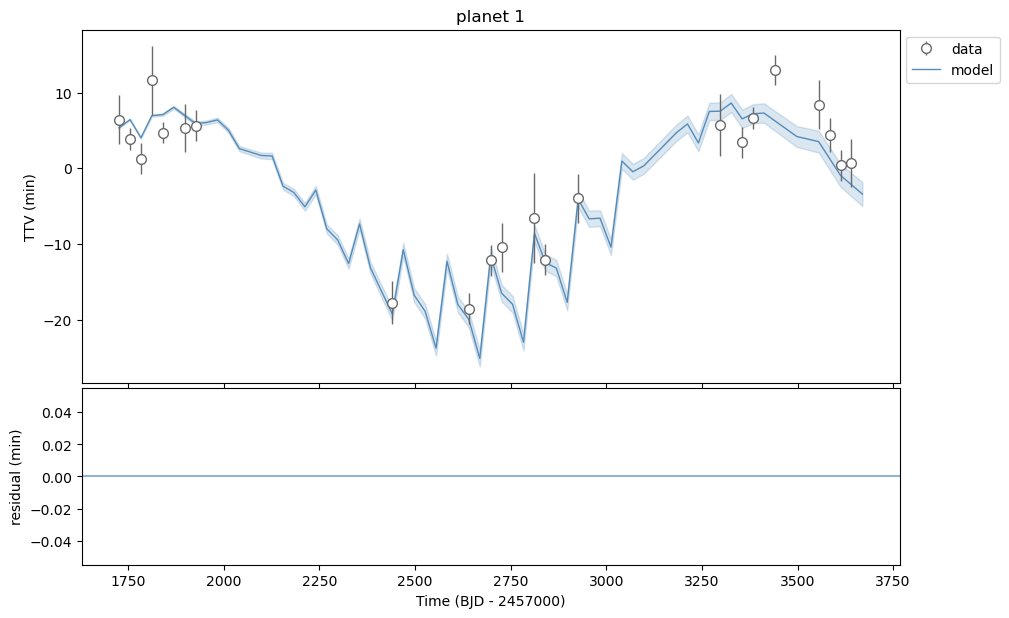

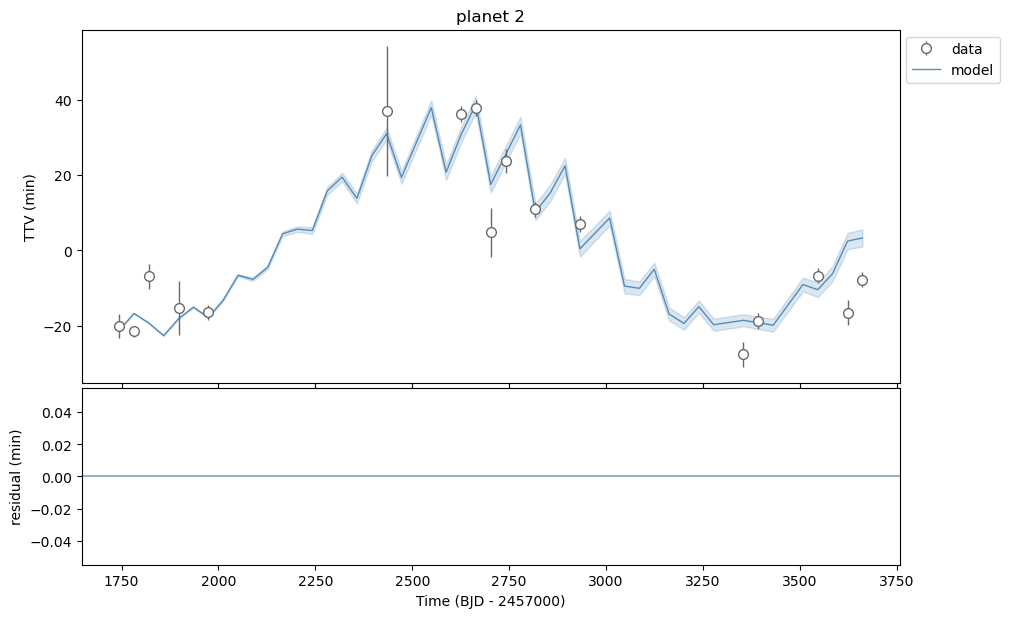

<Figure size 1920x1440 with 0 Axes>

In [31]:
jttv.plot_model(means, tcmodelunclist=stds, xlabel=f'Time (BJD - {TESS_offset})')
plt.figure(dpi=300) 

In [32]:
import arviz as az
# idata = az.from_numpyro(mcmc)
samples_sorted = mcmc.get_samples(group_by_chain=True)
idata = az.from_dict(posterior=samples_sorted)

OverflowError: cannot convert float infinity to integer

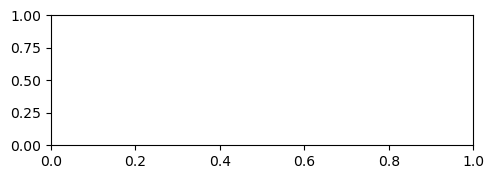

In [34]:
fig = az.plot_trace(idata, var_names=sample_keys, compact=False)
plt.figure(dpi=300) 
plt.tight_layout(pad=0.2)

In [ ]:
idata.posterior['pmass_e'] = idata.posterior['pmass'] / 3.003e-6
names = ["period", "ecc", "tic", "ecosw", "esinw", "pmass_e"]
fig = corner.corner(idata, var_names=names, show_titles=True)

In [ ]:
### 2D posterior for ecosw and esinw 
ecosw_b = samples["ecosw"][:, 0]
esinw_b = samples["esinw"][:, 0]

ecosw_c = samples["ecosw"][:, 1]
esinw_c = samples["esinw"][:, 1]

import matplotlib.pyplot as plt
# import seaborn as sns
from scipy.stats import gaussian_kde


def compute_kde_contour_levels(x, y, gridsize=100):
    data = np.vstack([x, y])
    kde = gaussian_kde(data)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    X, Y = np.mgrid[x_min:x_max:gridsize*1j, y_min:y_max:gridsize*1j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    return X, Y, Z, kde

def get_sigma_contour_levels(Z):
    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]
    levels = []
    for sigma in [0.683, 0.954]:
        idx = np.searchsorted(cumsum, sigma)
        levels.append(Z_sorted[idx])
    return sorted(levels)  # ensures ascending order

# Compute KDEs
Xb, Yb, Zb, kde_b = compute_kde_contour_levels(ecosw_b, esinw_b)
Xc, Yc, Zc, kde_c = compute_kde_contour_levels(ecosw_c, esinw_c)

# Get contour levels
levels_b = get_sigma_contour_levels(Zb)
levels_c = get_sigma_contour_levels(Zc)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Filled contours for planet b (blue shades)
ax.contourf(Xb, Yb, Zb, levels=levels_b + [Zb.max()], colors=['#a6cee3', '#1f78b4'], alpha=0.5)

# Filled contours for planet c (green shades)
ax.contourf(Xc, Yc, Zc, levels=levels_c + [Zc.max()], colors=['#b2df8a', '#33a02c'], alpha=0.5)

# Text annotation
ax.text(0.22, 0.27, 'TOI-1339c', color='#1f78b4', fontsize=16, ha='center')
ax.text(0.22, 0.23, 'TOI-1339d', color='#33a02c', fontsize=16, ha='center')


# Labels and legend
ax.set_xlabel(r"$e \cos\omega$", fontsize=16)
ax.set_ylabel(r"$e \sin\omega$", fontsize=16)
# ax.set_title("2D Joint Posterior of $e  cos(\omega)$ and $e sin(\omega)$")
blue_patch = plt.Line2D([], [], color='#a6cee3', label='Planet b')
red_patch = plt.Line2D([], [], color='#b2df8a', label='Planet c')
# ax.legend(handles=[blue_patch, red_patch])


# plt.grid(True)
plt.tick_params(axis='both', labelsize=13) 
# plt.xlim(-0.40,0.40)
# plt.ylim(-0.40,0.40)
plt.grid(True)
plt.tight_layout()
plt.show()